## Set-up

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Loading MNIST dataset

In [3]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


## Visualizing the dataset

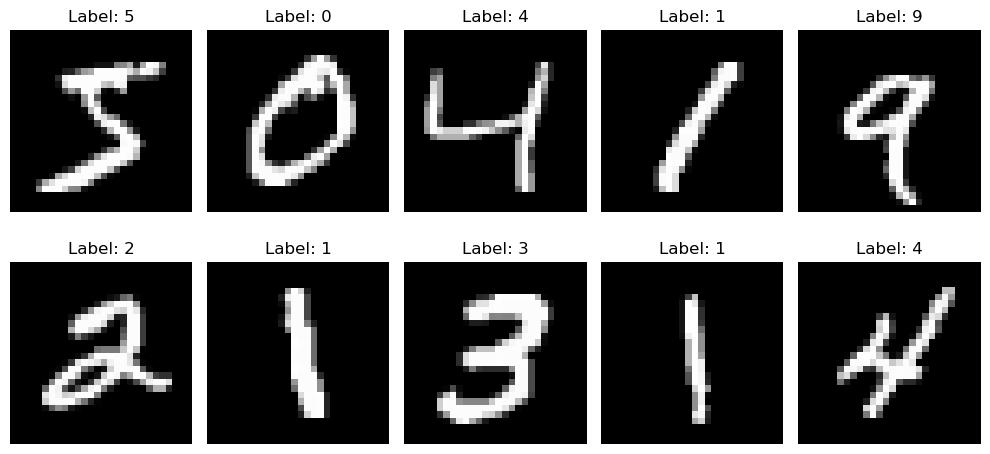

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
print("Image Shape:", x_train[0].shape)
print("Label:", y_train[0])

Image Shape: (28, 28)
Label: 5


## Scaling and Pre-processing

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [7]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


## CNN Architecture

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

C:\Users\shiva\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


## Training the CNN

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.9596 - loss: 0.1324 - val_accuracy: 0.9841 - val_loss: 0.0455
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9862 - loss: 0.0440 - val_accuracy: 0.9888 - val_loss: 0.0335
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9911 - loss: 0.0290 - val_accuracy: 0.9884 - val_loss: 0.0347
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9910 - val_loss: 0.0269
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9950 - loss: 0.0155 - val_accuracy: 0.9925 - val_loss: 0.0232


## Evaluating the model

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9925 - loss: 0.0232
Test Loss: 0.023186620324850082
Test Accuracy: 0.9925000071525574


## Saving the model

In [13]:
model.save("../models/mnist_cnn_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


## Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


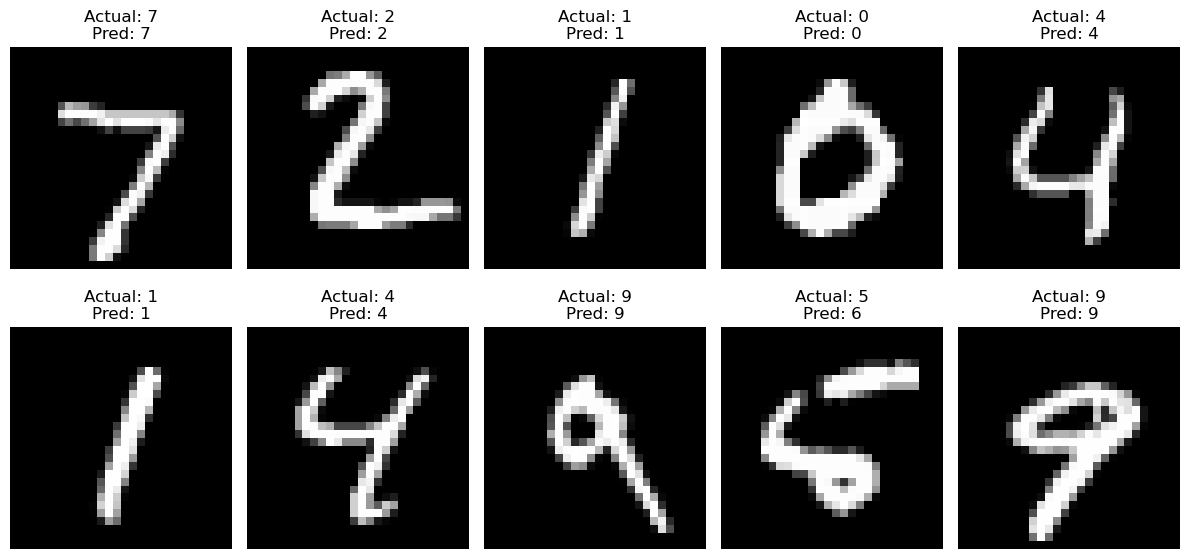

In [14]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(x_test)

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(
        f"Actual: {y_test[i]}\nPred: {np.argmax(predictions[i])}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

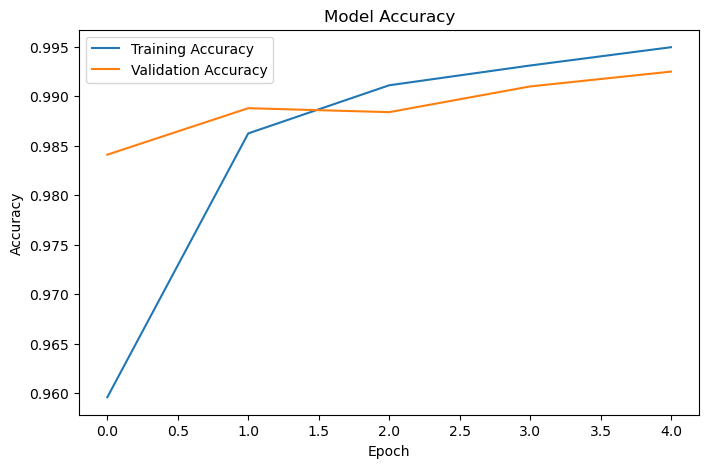

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# EMNIST Character Recognition

In [16]:
import tensorflow_datasets as tfds

print("TFDS Loaded Successfully")

TFDS Loaded Successfully


## Loading EMNIST dataset

In [17]:
import tensorflow_datasets as tfds

emnist_train, emnist_info = tfds.load(
    'emnist/letters',
    split='train',
    with_info=True,
    as_supervised=True
)

print(emnist_info)

tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='C:\\Users\\shiva\\tensorflow_datasets\\emnist\\letters\\3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    }),
    

## Visualize EMNIST Letters

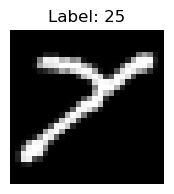

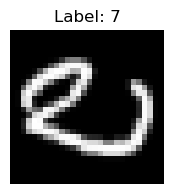

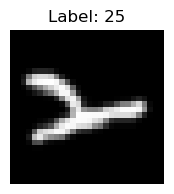

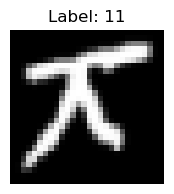

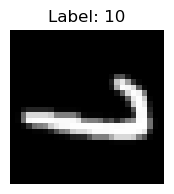

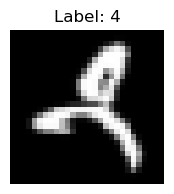

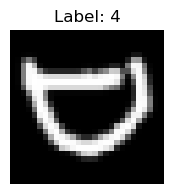

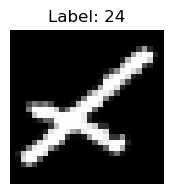

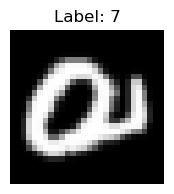

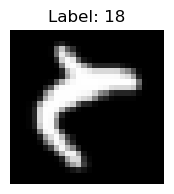

In [18]:
import matplotlib.pyplot as plt

for image, label in emnist_train.take(10):
    plt.figure(figsize=(2, 2))
    plt.imshow(image.numpy().squeeze(), cmap="gray")
    plt.title(f"Label: {label.numpy()}")
    plt.axis("off")
    plt.show()

In [19]:
print(emnist_info.full_name)

emnist/letters/3.1.0


## Correcting the orientations

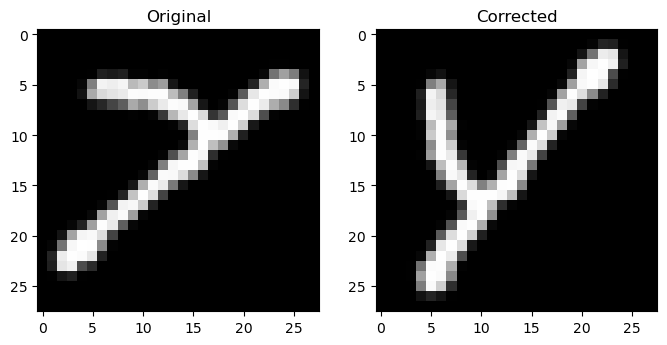

Label: 25


In [20]:
for image, label in emnist_train.take(1):
    img = image.numpy().squeeze()

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(np.flipud(np.rot90(img)), cmap='gray')
    plt.title("Corrected")

    plt.show()

    print("Label:", label.numpy())

In [21]:
for image, label in emnist_train.take(10):
    letter = chr(label.numpy() + 64)
    print(f"Label: {label.numpy()}  ->  Letter: {letter}")

Label: 25  ->  Letter: Y
Label: 7  ->  Letter: G
Label: 25  ->  Letter: Y
Label: 11  ->  Letter: K
Label: 10  ->  Letter: J
Label: 4  ->  Letter: D
Label: 4  ->  Letter: D
Label: 24  ->  Letter: X
Label: 7  ->  Letter: G
Label: 18  ->  Letter: R


## Convert EMNIST to NumPy Arrays

In [22]:
images = []
labels = []

for image, label in tfds.as_numpy(emnist_train):
    img = np.flipud(np.rot90(image.squeeze()))

    images.append(img)
    labels.append(label - 1)

images = np.array(images)
labels = np.array(labels)

print(images.shape)
print(labels.shape)

(88800, 28, 28)
(88800,)


In [23]:
print("Min Label:", labels.min())
print("Max Label:", labels.max())

Min Label: 0
Max Label: 25


## Scaling 

In [24]:
images = images / 255.0

print(images.min())
print(images.max())

0.0
1.0


## Reshape for CNN

In [25]:
images = images.reshape(-1, 28, 28, 1)

print(images.shape)

(88800, 28, 28, 1)


## Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

x_train_emnist, x_test_emnist, y_train_emnist, y_test_emnist = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(x_train_emnist.shape)
print(x_test_emnist.shape)

(71040, 28, 28, 1)
(17760, 28, 28, 1)


## Building the EMNIST CNN

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

emnist_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(26, activation='softmax')
])

C:\Users\shiva\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
emnist_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

In [29]:
emnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the EMNIST Character Recognition Model

In [30]:
history_emnist = emnist_model.fit(
    x_train_emnist,
    y_train_emnist,
    epochs=10,
    validation_data=(x_test_emnist, y_test_emnist),
    batch_size=128
)

Epoch 1/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.7317 - loss: 0.8771 - val_accuracy: 0.8779 - val_loss: 0.3759
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.8631 - loss: 0.4236 - val_accuracy: 0.9049 - val_loss: 0.2913
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.8861 - loss: 0.3484 - val_accuracy: 0.9100 - val_loss: 0.2662
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9013 - loss: 0.3024 - val_accuracy: 0.9187 - val_loss: 0.2486
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9087 - loss: 0.2766 - val_accuracy: 0.9235 - val_loss: 0.2302
Epoch 6/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9159 - loss: 0.2514 - val_accuracy: 0.9219 - val_loss: 0.2334
Epoch 7/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9210 - loss: 0.2329 - val_accuracy: 0.9262 - val_loss: 0.2230
Epoch 8/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.9274 - loss: 0.2148 - 

In [31]:
test_loss, test_accuracy = emnist_model.evaluate(
    x_test_emnist,
    y_test_emnist
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

555/555 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9285 - loss: 0.2188
Test Accuracy: 0.9285473227500916
Test Loss: 0.2187742441892624


## Saving the EMNIST model

In [32]:
emnist_model.save("../models/emnist_character_model.h5")

print("EMNIST Model Saved Successfully!")

EMNIST Model Saved Successfully!


In [33]:
predictions = emnist_model.predict(x_test_emnist[:10])

for i in range(10):
    predicted_label = np.argmax(predictions[i])
    actual_label = y_test_emnist[i]

    predicted_char = chr(predicted_label + 65)
    actual_char = chr(actual_label + 65)

    print(
        f"Actual: {actual_char} | Predicted: {predicted_char}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Actual: T | Predicted: T
Actual: F | Predicted: F
Actual: M | Predicted: M
Actual: I | Predicted: L
Actual: C | Predicted: C
Actual: K | Predicted: H
Actual: U | Predicted: U
Actual: H | Predicted: H
Actual: L | Predicted: L
Actual: S | Predicted: S


## visualizing predict

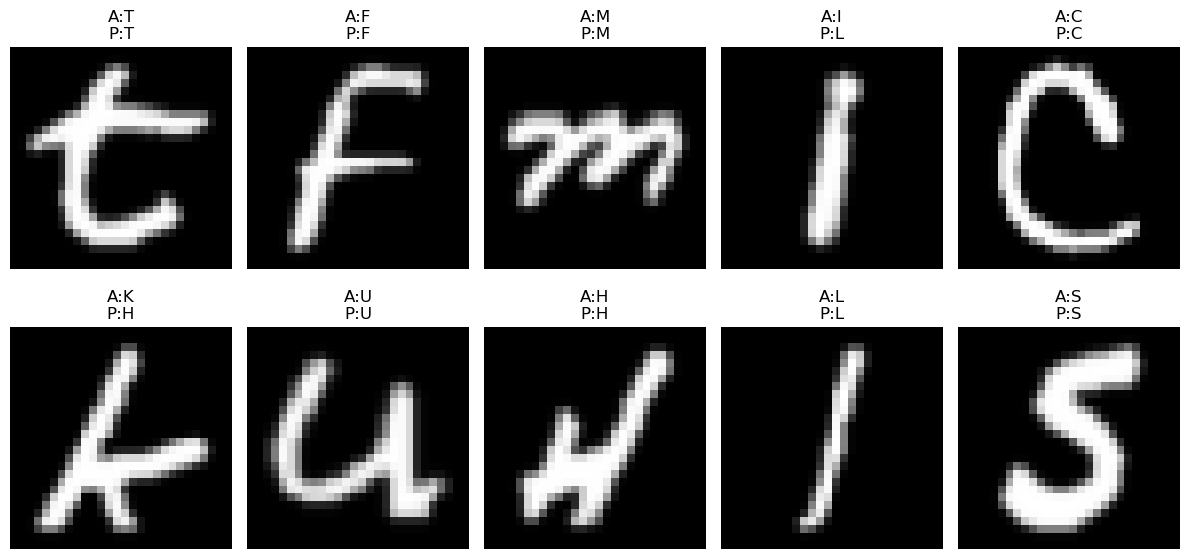

In [34]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test_emnist[i].reshape(28, 28),
        cmap='gray'
    )

    pred = chr(np.argmax(predictions[i]) + 65)
    actual = chr(y_test_emnist[i] + 65)

    plt.title(f"A:{actual}\nP:{pred}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
emnist_model.save("../models/emnist_character_model.keras")

In [36]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [37]:
emnist_model.export("../models/emnist_savedmodel")

INFO:tensorflow:Assets written to: ../models/emnist_savedmodel\assets


INFO:tensorflow:Assets written to: ../models/emnist_savedmodel\assets


Saved artifact at '../models/emnist_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  1938838930640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838931600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838931408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838931984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838931792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838932368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838931024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1938838933136: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [38]:
loaded = tf.saved_model.load("../models/emnist_savedmodel")
print("SavedModel created successfully")

SavedModel created successfully
